In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ⚡ Transformer Baseline — Production-Ready Load Forecaster
## Sri Lanka Electricity Demand Forecasting

This notebook implements a **Transformer-based** time-series forecaster for multi-step electricity demand prediction.

---

### 🏗️ Model Architecture

```
Input (196 timesteps × N features)
  → Dense Embedding (d_model=64)
  → Positional Encoding (sinusoidal)
  → TransformerBlock × 4
      └─ MultiHeadAttention (4 heads)
      └─ FeedForward (d_ff=256)
      └─ LayerNorm + Residuals
  → GlobalAveragePooling1D
  → Dense(64) + Dropout
  → Output (4 steps ahead)
```

### ✨ Key Features

| Feature | Detail |
|---------|--------|
| **Multi-step forecast** | Predicts 4 steps ahead (1 hour) |
| **Mixed precision** | float16 compute for faster inference |
| **AdamW + gradient clipping** | Stable training with weight decay |
| **Per-step metrics** | MAE/RMSE/MAPE/R² for each forecast horizon step |
| **Latency benchmark** | Single & batch inference timing |
| **Production config** | JSON artifact for deployment |

---

### 📋 Pipeline Overview

| Step | Description |
|------|-------------|
| 0 | Imports, GPU setup & logging |
| 1 | Configuration |
| 2 | Load data |
| 3 | Feature engineering |
| 4 | Temporal split & scaling |
| 5 | Sliding-window sequences |
| 6 | Positional encoding & Transformer block |
| 7 | Build & compile model |
| 8 | Train with callbacks |
| 9 | Evaluate (per-step metrics) |
| 10 | Latency benchmark |
| 11 | Visualize results |
| 12 | Save production config |

## 0️⃣ Imports, GPU Setup & Logging

In [41]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import time
from pathlib import Path
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Enable mixed precision (float16 compute → faster on modern GPUs)
# tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ── Allow GPU memory to grow on demand (avoids OOM crashes)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

# ── Fix random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Output directory for all saved artifacts
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

print("Setup complete ✅")
print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")

Setup complete ✅
TensorFlow version : 2.20.0
GPUs available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [42]:
def log(msg, level="INFO"):
    """Timestamped logging for production traceability."""
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{ts}] {level:<8} {msg}")

## 1️⃣ Configuration

All hyperparameters and paths are stored in a single `CONFIG` dictionary.
This makes it easy to tune, log, and reproduce any experiment.

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `lookback` | 196 | ~49 hours of 15-min history per sample |
| `horizon` | 4 | Predict 4 steps ahead (= 1 hour) |
| `d_model` | 64 | Transformer embedding dimension |
| `n_heads` | 4 | Number of attention heads |
| `d_ff` | 256 | Feedforward hidden dimension |
| `n_blocks` | 4 | Number of stacked Transformer blocks |

In [43]:
CONFIG = {
    # ── Data
    "file_path"      : "/content/drive/MyDrive/Colab Notebooks/electricity_demand_srilanka_fixed.csv",
    "target_col"     : "Load Demand (kW)",
    "timestamp_col"  : "Timestamp",

    # ── Sequence
    "lookback"       : 168,
    "horizon"        : 4,     # predict 4 steps (1 hour) ahead

    # ── Split ratios (train 80% | val 10% | test 10%)
    "train_ratio"    : 0.70,
    "val_ratio"      : 0.15,
    "test_ratio"     : 0.15,

    # ── Training
    "batch_size"     : 128,
    "epochs"         : 150,
    "learning_rate"  : 1e-3,
    "early_stop_patience"  : 20,
    "early_stop_min_delta" : 1e-4,

    # ── Transformer architecture
    "d_model"        : 96,    # embedding dimension
    "n_heads"        : 4,     # attention heads (d_model must be divisible by n_heads)
    "d_ff"           : 384,   # feedforward hidden size
    "n_blocks"       : 4,     # stacked Transformer blocks
    "dropout_rate"   : 0.15,
    "layer_norm_eps" : 1e-6,
}

log(f"Configuration loaded: lookback={CONFIG['lookback']}, horizon={CONFIG['horizon']}, "
    f"d_model={CONFIG['d_model']}, n_blocks={CONFIG['n_blocks']}")

[2026-07-16 07:32:46] INFO     Configuration loaded: lookback=168, horizon=4, d_model=96, n_blocks=4


## 2️⃣ Load Data

We load the CSV, parse timestamps, sort chronologically, and use the **full dataset** (no COVID filtering for this model).

In [44]:
# ── Load CSV and set datetime index
df = pd.read_csv(CONFIG["file_path"], parse_dates=[CONFIG["timestamp_col"]])
df = df.sort_values(CONFIG["timestamp_col"]).reset_index(drop=True)
df = df.set_index(CONFIG["timestamp_col"])

# Remove 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    log(f"'Unnamed: 0' column removed. Current columns: {list(df.columns)}")

if len(df) == 0:
    raise ValueError("❌ Empty dataset — check file path")

log(f"Loaded {len(df):,} rows  |  {df.index[0]}  →  {df.index[-1]}")
log(f"Columns: {list(df.columns)}")
df.head(3)

[2026-07-16 07:32:48] INFO     'Unnamed: 0' column removed. Current columns: ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'GDP (LKR)', 'Per Capita Energy Use (kWh)', 'Electricity Price (LKR/kWh)', 'Day of Week', 'Hour of Day', 'Month', 'Season', 'Public Event', 'Load Demand (kW)', 'Poya Day']
[2026-07-16 07:32:48] INFO     Loaded 189,888 rows  |  2020-01-01 00:00:00  →  2025-05-31 23:45:00
[2026-07-16 07:32:48] INFO     Columns: ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'GDP (LKR)', 'Per Capita Energy Use (kWh)', 'Electricity Price (LKR/kWh)', 'Day of Week', 'Hour of Day', 'Month', 'Season', 'Public Event', 'Load Demand (kW)', 'Poya Day']


,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Poya Day
Timestamp,,,,,,,,,,,,,,,
2020-01-01 00:00:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1202.4797,0
2020-01-01 00:15:00,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1213.1439,0
2020-01-01 00:30:00,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1215.3267,0


## 3️⃣ Feature Engineering

Same safe feature set as the CNN-LSTM baseline:

- **Cyclic encodings** — hour, day-of-week, month (sin/cos pairs)
- **Lag features** — anchored at `shift(96)` = 24h ago or further → **zero leakage**
- **Rolling stats** — 7-day mean and 24h std, also anchored 24h back

In [45]:
# ── Cyclic time encodings
df["sin_hour"]  = np.sin(2 * np.pi * df["Hour of Day"] / 24)
df["cos_hour"]  = np.cos(2 * np.pi * df["Hour of Day"] / 24)
df["sin_dow"]   = np.sin(2 * np.pi * df["Day of Week"] / 7)
df["cos_dow"]   = np.cos(2 * np.pi * df["Day of Week"] / 7)
df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)

df["is_weekend"] = (df["Day of Week"] >= 5).astype(int)
df["year_norm"]  = (df.index.year - 2022) / 3

df["load_lag_96"]  = df[CONFIG["target_col"]].shift(96)
df["load_lag_192"] = df[CONFIG["target_col"]].shift(192)
df["load_lag_672"] = df[CONFIG["target_col"]].shift(96 * 7)

df["load_mean_week"] = df[CONFIG["target_col"]].shift(96).rolling(96 * 7).mean()
df["load_std_day"]   = df[CONFIG["target_col"]].shift(96).rolling(96).std()

# ── Structural break flags
def add_structural_break_features(df):
    df['is_covid_lockdown'] = 0
    df['is_economic_crisis'] = 0
    df.loc['2020-03-20':'2020-05-11', 'is_covid_lockdown'] = 1
    df.loc['2021-05-21':'2021-06-21', 'is_covid_lockdown'] = 1
    df.loc['2022-03-01':'2022-08-31', 'is_economic_crisis'] = 1
    return df

df = add_structural_break_features(df)

# ── Sample weights: down-weight anomalous periods instead of feeding as a feature
df['sample_weight'] = 1.0
df.loc[df['is_covid_lockdown'] == 1, 'sample_weight'] = 0.3
df.loc[df['is_economic_crisis'] == 1, 'sample_weight'] = 0.3

# ── Drop NaN rows created by lags/rolling
df.dropna(inplace=True)

In [46]:
# ── Define feature list (only keep columns that exist in the dataframe)
FEATURE_COLS = [
    "Temperature (°C)", "Humidity (%)", "Wind Speed (m/s)",
    "Rainfall (mm)", "Solar Irradiance (W/m²)",
    "sin_hour", "cos_hour", "sin_dow", "cos_dow",
    "sin_month", "cos_month", "is_weekend", "year_norm",
    "Public Event", "Poya Day",
    "load_lag_96", "load_lag_192", "load_lag_672",
    "load_mean_week", "load_std_day",

]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f"Total features : {len(FEATURE_COLS)}")

# ── Leakage check: flag any feature with |corr| > 0.98
print(f"\n{'Feature':<35}  Correlation with Target")
print("-" * 65)
for col in FEATURE_COLS:
    corr = df[col].corr(df[CONFIG["target_col"]])
    flag = "  ⚠️  HIGH — CHECK FOR LEAKAGE" if abs(corr) > 0.98 else ""
    print(f"  {col:<35} {corr:+.4f}{flag}")

Total features : 20

Feature                              Correlation with Target
-----------------------------------------------------------------
  Temperature (°C)                    +0.0132
  Humidity (%)                        +0.0015
  Wind Speed (m/s)                    +0.0016
  Rainfall (mm)                       -0.0024
  Solar Irradiance (W/m²)             -0.0044
  sin_hour                            +0.0636
  cos_hour                            -0.6127
  sin_dow                             +0.1589
  cos_dow                             -0.1787
  sin_month                           +0.2942
  cos_month                           -0.0485
  is_weekend                          -0.2134
  year_norm                           +0.6628
  Public Event                        -0.0642
  Poya Day                            -0.1162
  load_lag_96                         +0.9139
  load_lag_192                        +0.8584
  load_lag_672                        +0.9505
  load_mean_week        

## 4️⃣ Temporal Split & Scaling

**Rules for time-series splits:**
1. Always split **chronologically** — never shuffle
2. **Fit scalers on training data only** — applying fit on all data leaks future statistics
3. Features and target are scaled **separately** so the target can be inverted independently

In [47]:
n       = len(df)
n_train = int(n * CONFIG["train_ratio"])
n_val   = int(n * CONFIG["val_ratio"])

# ── Chronological split
df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train : n_train + n_val]
df_test  = df.iloc[n_train + n_val :]

w_train = df_train['sample_weight'].values

log(f"Train : {len(df_train):,}  ({df_train.index[0].date()} → {df_train.index[-1].date()})")
log(f"Val   : {len(df_val):,}  ({df_val.index[0].date()} → {df_val.index[-1].date()})")
log(f"Test  : {len(df_test):,}  ({df_test.index[0].date()} → {df_test.index[-1].date()})")

[2026-07-16 07:32:51] INFO     Train : 132,384  (2020-01-08 → 2023-10-18)
[2026-07-16 07:32:51] INFO     Val   : 28,368  (2023-10-18 → 2024-08-09)
[2026-07-16 07:32:51] INFO     Test  : 28,369  (2024-08-09 → 2025-05-31)


In [48]:
 # ── Fit scalers on training data only
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()

X_tr_raw = feat_scaler.fit_transform(df_train[FEATURE_COLS])     # fit + transform
y_tr_raw = target_scaler.fit_transform(df_train[[CONFIG["target_col"]]])

X_vl_raw = feat_scaler.transform(df_val[FEATURE_COLS])           # transform only!
y_vl_raw = target_scaler.transform(df_val[[CONFIG["target_col"]]])

X_te_raw = feat_scaler.transform(df_test[FEATURE_COLS])
y_te_raw = target_scaler.transform(df_test[[CONFIG["target_col"]]])

# ── Save scalers for deployment inference
joblib.dump(feat_scaler,   OUT_DIR / "feat_scaler.pkl")
joblib.dump(target_scaler, OUT_DIR / "target_scaler.pkl")
log("Scalers saved ✅")

[2026-07-16 07:32:52] INFO     Scalers saved ✅


## 5️⃣ Build Sliding-Window Sequences

Each sample:
- **X[i]** = features from step `i` to `i + lookback` (196 timesteps ≈ 49 hours)
- **y[i]** = next `horizon` (4) target values

This gives the model **multi-step output** — it predicts 4 values at once instead of just 1.

In [49]:
def build_sequences(X, y, lookback, horizon=1):
    """
    Convert flat time-series arrays into overlapping (X, y) windows.

    Args:
        X        : 2D feature array  (timesteps × n_features)
        y        : 2D target array   (timesteps × 1)
        lookback : past steps used as model input
        horizon  : future steps to predict (multi-step output)

    Returns:
        Xs : float32 array  (n_samples × lookback × n_features)
        ys : float32 array  (n_samples × horizon)
    """
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback : i + lookback + horizon, 0])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

def build_sample_weights(w, lookback, horizon):
    return np.array([w[i + lookback] for i in range(len(w) - lookback - horizon + 1)], dtype=np.float32)

sw_tr = build_sample_weights(w_train, CONFIG["lookback"], CONFIG["horizon"])


X_tr, y_tr = build_sequences(X_tr_raw, y_tr_raw, CONFIG["lookback"], CONFIG["horizon"])
X_vl, y_vl = build_sequences(X_vl_raw, y_vl_raw, CONFIG["lookback"], CONFIG["horizon"])
X_te, y_te = build_sequences(X_te_raw, y_te_raw, CONFIG["lookback"], CONFIG["horizon"])

log(f"Train  X: {X_tr.shape}  y: {y_tr.shape}")
log(f"Val    X: {X_vl.shape}  y: {y_vl.shape}")
log(f"Test   X: {X_te.shape}  y: {y_te.shape}")

# ── Guard against silent bugs
assert y_tr.std() > 0.01, "❌ Target variance near zero — check sequence building!"
log(f"Target stats — mean: {y_tr.mean():.4f}  std: {y_tr.std():.4f}  ✅")

[2026-07-16 07:32:55] INFO     Train  X: (132213, 168, 20)  y: (132213, 4)
[2026-07-16 07:32:55] INFO     Val    X: (28197, 168, 20)  y: (28197, 4)
[2026-07-16 07:32:55] INFO     Test   X: (28198, 168, 20)  y: (28198, 4)
[2026-07-16 07:32:55] INFO     Target stats — mean: 0.0005  std: 1.0002  ✅


## 6️⃣ Model Components

### Positional Encoding
Transformers have no built-in sense of order — positional encoding adds position information using sinusoidal waves. Each position gets a unique pattern across the `d_model` dimensions.

### Transformer Block
Each block has two sub-layers with residual connections:
1. **Multi-Head Attention** — learns which past timesteps to attend to
2. **FeedForward** — applies a non-linear transformation to each position independently

In [50]:
class PositionalEncoding(tf.keras.layers.Layer):
    """
    Sinusoidal positional encoding (Vaswani et al., 2017).
    Adds a unique position signal to each timestep in the sequence.
    """
    def __init__(self, max_seq_len, d_model, **kwargs):
        super().__init__(**kwargs)

        # Build (max_seq_len × d_model) encoding matrix
        pe       = np.zeros((max_seq_len, d_model))
        position = np.arange(0, max_seq_len, dtype=np.float32)[:, np.newaxis]
        div_term = np.exp(
            np.arange(0, d_model, 2, dtype=np.float32) * -(np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = np.sin(position * div_term)   # even indices
        pe[:, 1::2] = np.cos(position * div_term)   # odd indices

        # Match mixed-precision compute dtype to avoid dtype mismatch errors
        compute_dtype = tf.keras.mixed_precision.global_policy().compute_dtype
        self.pe = tf.constant(pe[np.newaxis, :, :], dtype=compute_dtype)

    def call(self, x):
        # Add positional signal to the input embeddings
        return x + self.pe[:, :tf.shape(x)[1], :]

In [51]:
class TransformerBlock(tf.keras.layers.Layer):
    """
    A single Transformer encoder block:
      1. Multi-Head Self-Attention  (with residual + LayerNorm)
      2. Position-wise FeedForward  (with residual + LayerNorm)

    Args:
        d_model  : embedding dimension
        n_heads  : number of attention heads
        d_ff     : hidden units in the feedforward layer
        dropout  : dropout rate applied after attention and feedforward
    """
    def __init__(self, d_model, n_heads, d_ff, dropout, **kwargs):
        super().__init__(**kwargs)

        # ── Attention sub-layer
        self.mha      = MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model // n_heads, dropout=dropout
        )
        self.norm1    = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout)

        # ── FeedForward sub-layer
        self.ff1      = Dense(d_ff, activation="relu")
        self.ff2      = Dense(d_model)
        self.norm2    = LayerNormalization(epsilon=1e-6)
        self.dropout2 = Dropout(dropout)

    def call(self, x, training=False):
        # ── Sub-layer 1: Multi-Head Attention + residual
        attn_out = self.mha(x, x, training=training)
        attn_out = self.dropout1(attn_out, training=training)
        x = self.norm1(x + attn_out)             # residual connection

        # ── Sub-layer 2: FeedForward + residual
        ff_out = self.ff2(self.ff1(x))
        ff_out = self.dropout2(ff_out, training=training)
        x = self.norm2(x + ff_out)               # residual connection

        return x

## 7️⃣ Build & Compile the Model

**Why AdamW instead of Adam?**
> AdamW decouples weight decay from the gradient update — it regularises the weights directly rather than through the loss. This improves generalisation, especially for Transformers.

**Why gradient clipping (`clipnorm=1.0`)?**
> Attention gradients can explode early in training. Clipping keeps updates bounded and stabilises convergence.

In [52]:
n_steps    = CONFIG["lookback"]
n_features = X_tr.shape[2]

# ── Input
inp = Input(shape=(n_steps, n_features), name="input")

# ── Embedding: project raw features to d_model dimensions
x = Dense(CONFIG["d_model"], activation="relu", name="embed")(inp)

# ── Add positional encoding
x = PositionalEncoding(max_seq_len=n_steps, d_model=CONFIG["d_model"], name="pos_enc")(x)

# ── Stack Transformer blocks

for i in range(CONFIG["n_blocks"]):
    x = TransformerBlock(
        d_model  = CONFIG["d_model"],
        n_heads  = CONFIG["n_heads"],
        d_ff     = CONFIG["d_ff"],
        dropout  = CONFIG["dropout_rate"],
        name     = f"transformer_block_{i}"
    )(x)

# ── Aggregate all timesteps into a single vector
x = GlobalAveragePooling1D(name="pool")(x)

# ── Output head
x   = Dense(64, activation="relu", name="dense_out")(x)
x   = Dropout(CONFIG["dropout_rate"], name="drop_out")(x)
out = Dense(CONFIG["horizon"], dtype="float32", name="output")(x)


model = Model(inp, out, name="TransformerBaseline")

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=CONFIG["learning_rate"],
        weight_decay=1e-4,
        clipnorm=1.0,
    ),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)

log(f"Model: {model.name}  |  Parameters: {model.count_params():,}")
model.summary()

[2026-07-16 07:32:56] INFO     Model: TransformerBaseline  |  Parameters: 455,844


Model: "TransformerBaseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 168, 20)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed (Dense)                   │ (None, 168, 96)        │         2,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_enc (PositionalEncoding)    │ (None, 168, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 168, 96)        │       111,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 168, 96)        │       111,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 168, 96)        │       111,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 168, 96)        │       111,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool (GlobalAveragePooling1D)   │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_out (Dense)               │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_out (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,844 (1.74 MB)

 Trainable params: 455,844 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

## 8️⃣ Train the Model

| Callback | Setting | Purpose |
|----------|---------|---------|
| `EarlyStopping` | patience=20 | Stop when val_loss stalls; 20 epochs allows LR reductions to take effect |
| `ReduceLROnPlateau` | factor=0.5, patience=10 | Halve learning rate when stuck |
| `ModelCheckpoint` | save_best_only | Save best weights independently as a safety net |

> ⚠️ `shuffle=False` is **mandatory** — shuffling time-series batches causes future data to leak into training.

In [53]:
class WarmupLR(tf.keras.callbacks.Callback):
    def __init__(self, target_lr, warmup_epochs):
        super().__init__()
        self.target_lr = target_lr
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.target_lr * (epoch + 1) / self.warmup_epochs
            self.model.optimizer.learning_rate.assign(lr)

ckpt_path = str(OUT_DIR / "transformer_baseline.keras")

callbacks = [
    WarmupLR(target_lr=CONFIG["learning_rate"], warmup_epochs=5),
    EarlyStopping(
        monitor="val_loss",
        patience=CONFIG["early_stop_patience"],
        min_delta=CONFIG["early_stop_min_delta"],
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-5,
        verbose=1,
    ),
    ModelCheckpoint(
        ckpt_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    ),
]

history = model.fit(
    X_tr, y_tr,
    sample_weight=sw_tr,
    validation_data=(X_vl, y_vl),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=callbacks,
    shuffle=False,
    verbose=1,
)

model.load_weights(ckpt_path)
log(f"Best model loaded from: {ckpt_path} ✅")

Epoch 1/150
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 86s 54ms/step - loss: 0.0726 - mae: 0.3122 - rmse: 0.4134 - val_loss: 0.5565 - val_mae: 0.9924 - val_rmse: 1.1068 - learning_rate: 2.0000e-04
Epoch 2/150
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - loss: 0.0449 - mae: 0.2428 - rmse: 0.3218 - val_loss: 0.5708 - val_mae: 1.0040 - val_rmse: 1.1245 - learning_rate: 4.0000e-04
Epoch 3/150
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - loss: 0.0348 - mae: 0.2101 - rmse: 0.2818 - val_loss: 0.5964 - val_mae: 1.0270 - val_rmse: 1.1576 - learning_rate: 6.0000e-04
Epoch 4/150
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.0396 - mae: 0.2192 - rmse: 0.3013 - val_loss: 0.5400 - val_mae: 0.9624 - val_rmse: 1.0878 - learning_rate: 8.0000e-04
Epoch 5/150
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - loss: 0.0297 - mae: 0.1920 - rmse: 0.2590 - val_loss: 0.5461 - val_mae: 0.9547 - val_rmse: 1.1025 - learning_rate: 0.0010
Epoch 6/150
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - loss: 0.0282 - mae: 

## 9️⃣ Evaluate — Per-Step Metrics

Because we predict `horizon=4` steps, we report metrics **for each step separately** (step 1 = next 15 min, step 4 = next 1 hour) plus an **overall average**.

| Metric | Meaning |
|--------|---------|
| **MAE** | Mean Absolute Error in kW |
| **RMSE** | Root Mean Squared Error (penalises large errors more) |
| **MAPE** | Mean Absolute Percentage Error (%) |
| **R²** | Coefficient of determination (1.0 = perfect) |

In [54]:
def inverse_transform_horizon(y, scaler):
    """
    Inverse-transform multi-horizon predictions back to kW.
    Reshapes (n_samples × horizon) → flat → inverse → back to (n_samples × horizon).
    """
    n_samples, horizon = y.shape
    y_flat    = y.reshape(-1, 1)
    y_inverse = scaler.inverse_transform(y_flat)
    return y_inverse.reshape(n_samples, horizon)


def compute_per_step_metrics(y_true, y_pred, horizon):
    """
    Compute MAE, RMSE, MAPE, R² for each forecast horizon step.
    Also returns an overall average across all steps.

    Args:
        y_true  : actual values  (n_samples × horizon)
        y_pred  : predicted values (n_samples × horizon)
        horizon : number of forecast steps

    Returns:
        dict with step-level and overall-average metrics
    """
    step_metrics = {}
    for i in range(horizon):
        yt = y_true[:, i]
        yp = y_pred[:, i]
        step_metrics[f"step_{i+1}"] = {
            "mae"      : float(mean_absolute_error(yt, yp)),
            "rmse"     : float(np.sqrt(mean_squared_error(yt, yp))),
            "mape"     : float(mean_absolute_percentage_error(yt, yp) * 100),
            "r2"       : float(r2_score(yt, yp)),
            "n_samples": int(len(yt)),
        }

    # Overall average across all horizon steps
    step_metrics["overall_average"] = {
        "mae" : float(np.mean([v["mae"]  for k, v in step_metrics.items() if k.startswith("step_")])),
        "rmse": float(np.mean([v["rmse"] for k, v in step_metrics.items() if k.startswith("step_")])),
        "mape": float(np.mean([v["mape"] for k, v in step_metrics.items() if k.startswith("step_")])),
        "r2"  : float(np.mean([v["r2"]   for k, v in step_metrics.items() if k.startswith("step_")])),
        "n_samples": int(len(y_true)),
    }
    return step_metrics


def evaluate_split(X, y_scaled, name):
    """Run inference and report per-step metrics for one split."""
    y_pred_scaled = model.predict(X, batch_size=CONFIG["batch_size"], verbose=0)

    y_true = inverse_transform_horizon(y_scaled,      target_scaler)
    y_pred = inverse_transform_horizon(y_pred_scaled, target_scaler)

    m = compute_per_step_metrics(y_true, y_pred, CONFIG["horizon"])
    avg = m["overall_average"]

    log(f"{name:5s} | MAE={avg['mae']:7.2f} kW | RMSE={avg['rmse']:7.2f} kW | "
        f"MAPE={avg['mape']:6.2f}% | R²={avg['r2']:.4f}")

    return y_true, y_pred, m

In [55]:
print("── Evaluation Results ──")
y_tr_true, y_tr_pred, m_train = evaluate_split(X_tr, y_tr, "Train")
y_vl_true, y_vl_pred, m_val   = evaluate_split(X_vl, y_vl, "Val")
y_te_true, y_te_pred, m_test  = evaluate_split(X_te, y_te, "Test")

# ── Per-step breakdown for test set
print("\n── Test Per-Step Breakdown ──")
print(f"{'Step':<10} {'MAE':>8} {'RMSE':>8} {'MAPE':>8} {'R²':>8}")
print("-" * 44)
for k, v in m_test.items():
    label = k.replace("step_", "Step ").replace("overall_average", "Average")
    print(f"{label:<10} {v['mae']:8.2f} {v['rmse']:8.2f} {v['mape']:7.2f}% {v['r2']:8.4f}")

# ── Save all metrics to JSON
all_metrics = {"train": m_train, "val": m_val, "test": m_test}
with open(OUT_DIR / "metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2)
log(f"Metrics saved → {OUT_DIR / 'metrics.json'}")

── Evaluation Results ──
[2026-07-16 07:55:46] INFO     Train | MAE=  91.65 kW | RMSE= 113.14 kW | MAPE=  5.83% | R²=0.8547
[2026-07-16 07:55:51] INFO     Val   | MAE=  84.54 kW | RMSE= 108.60 kW | MAPE=  4.22% | R²=0.7904
[2026-07-16 07:55:55] INFO     Test  | MAE=  91.88 kW | RMSE= 115.57 kW | MAPE=  4.46% | R²=0.7321

── Test Per-Step Breakdown ──
Step            MAE     RMSE     MAPE       R²
--------------------------------------------
Step 1        89.30   112.14    4.35%   0.7479
Step 2        90.54   114.15    4.40%   0.7388
Step 3        92.69   116.71    4.49%   0.7270
Step 4        94.97   119.28    4.59%   0.7148
Average       91.88   115.57    4.46%   0.7321
[2026-07-16 07:55:55] INFO     Metrics saved → outputs/metrics.json


## 🔟 Latency Benchmark

We measure real-world inference speed — important for production deployment where predictions must arrive within the 15-minute interval window.

| Metric | Meaning |
|--------|---------|
| **Single sample latency** | Time per request in a real-time API |
| **Batch latency** | Time per sample when processing in bulk |
| **Throughput** | Samples per second in batch mode |

In [56]:
# ── Single-sample latency (averaged over 100 runs for stability)
start = time.time()
for _ in range(100):
    _ = model.predict(X_te[:1], verbose=0)
single_ms = (time.time() - start) / 100 * 1000

# ── Batch latency (512 samples, averaged over 10 runs)
start = time.time()
for _ in range(10):
    _ = model.predict(X_te[:512], verbose=0)
batch_ms_per_sample = (time.time() - start) / 10 / 512 * 1000

log(f"Single sample latency  : {single_ms:.2f} ms")
log(f"Batch latency/sample   : {batch_ms_per_sample:.2f} ms")
log(f"Throughput             : {1000 / batch_ms_per_sample:.0f} samples/sec")

[2026-07-16 08:05:27] INFO     Single sample latency  : 89.81 ms
[2026-07-16 08:05:27] INFO     Batch latency/sample   : 0.81 ms
[2026-07-16 08:05:27] INFO     Throughput             : 1241 samples/sec


## 1️⃣1️⃣ Visualize Results

Four plots:
1. **Training curves** — loss over epochs
2. **7-day forecast** — actual vs predicted (step 1) with error shading
3. **Scatter plot** — actual vs predicted (step 1)
4. **Error analysis** — error distribution + error over time

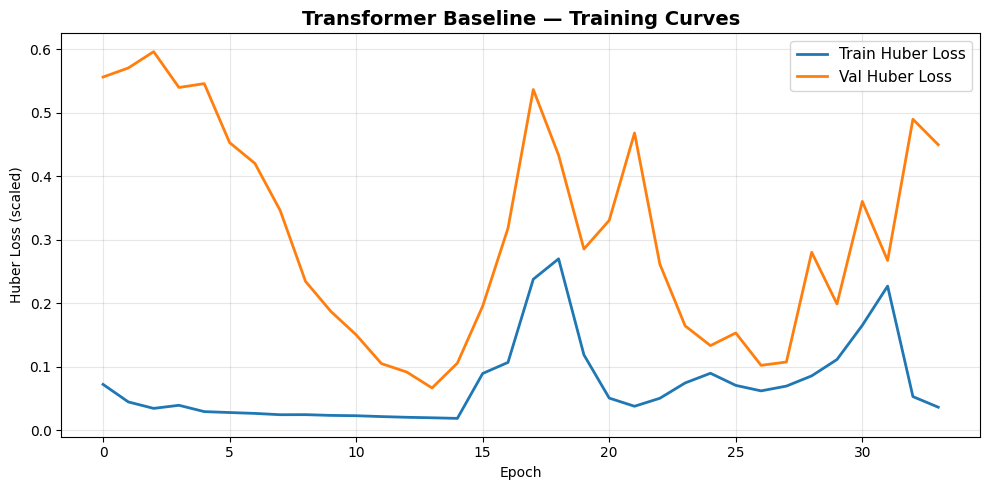

In [57]:
# ── Plot 1: Training & Validation Loss Curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["loss"],     label="Train Huber Loss", lw=2)
ax.plot(history.history["val_loss"], label="Val Huber Loss",   lw=2)
ax.set_title("Transformer Baseline — Training Curves", fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss (scaled)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves.png", dpi=150)
plt.show()

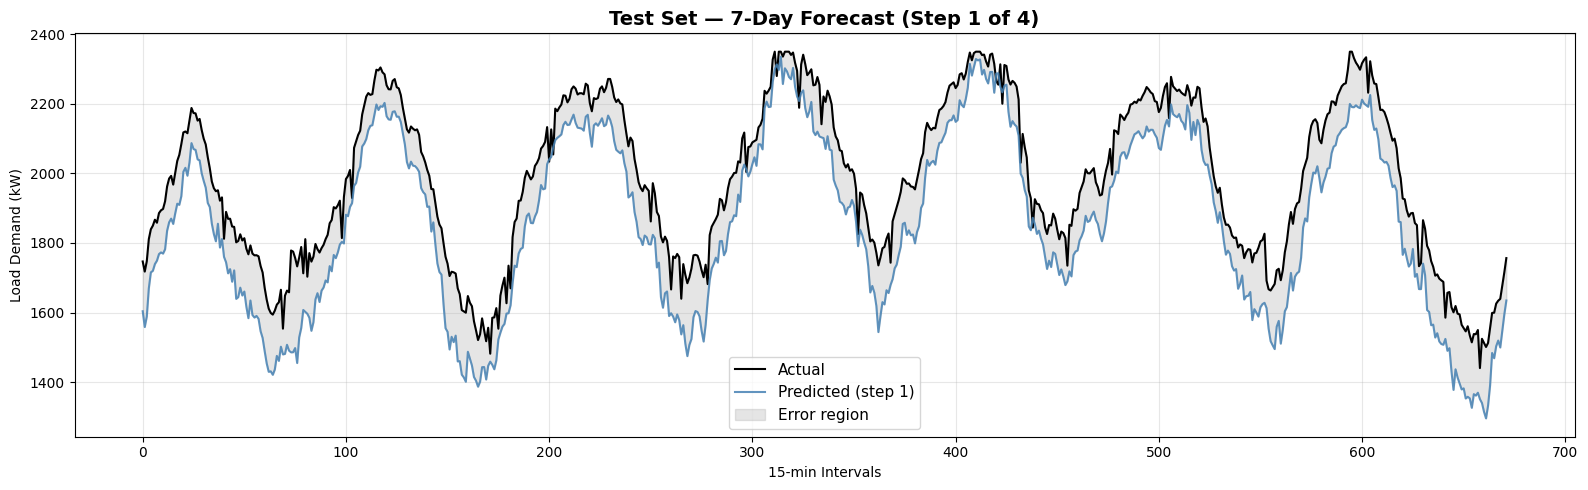

In [58]:
# ── Plot 2: 7-day forecast — actual vs predicted (step 1 of 4)
n_plot = min(4 * 24 * 7, len(y_te_true))   # 7 days of 15-min intervals

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_te_true[:n_plot, 0], lw=1.5, color="black",     label="Actual")
ax.plot(y_te_pred[:n_plot, 0], lw=1.5, color="steelblue", label="Predicted (step 1)", alpha=0.85)
ax.fill_between(
    np.arange(n_plot),
    y_te_true[:n_plot, 0],
    y_te_pred[:n_plot, 0],
    alpha=0.2, color="gray", label="Error region"
)
ax.set_title("Test Set — 7-Day Forecast (Step 1 of 4)", fontsize=14, fontweight="bold")
ax.set_xlabel("15-min Intervals")
ax.set_ylabel("Load Demand (kW)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "test_forecast.png", dpi=150)
plt.show()

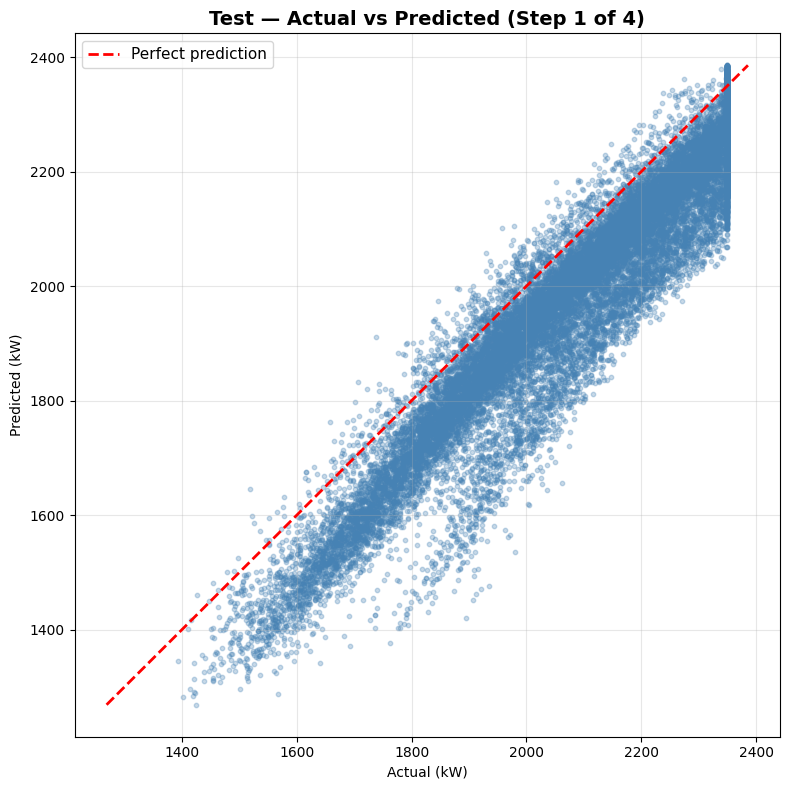

In [59]:
# ── Plot 3: Scatter — actual vs predicted (step 1)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_te_true[:, 0], y_te_pred[:, 0], alpha=0.3, s=10, color="steelblue")

lims = [
    min(y_te_true[:, 0].min(), y_te_pred[:, 0].min()),
    max(y_te_true[:, 0].max(), y_te_pred[:, 0].max()),
]
ax.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
ax.set_title("Test — Actual vs Predicted (Step 1 of 4)", fontsize=14, fontweight="bold")
ax.set_xlabel("Actual (kW)")
ax.set_ylabel("Predicted (kW)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "scatter.png", dpi=150)
plt.show()

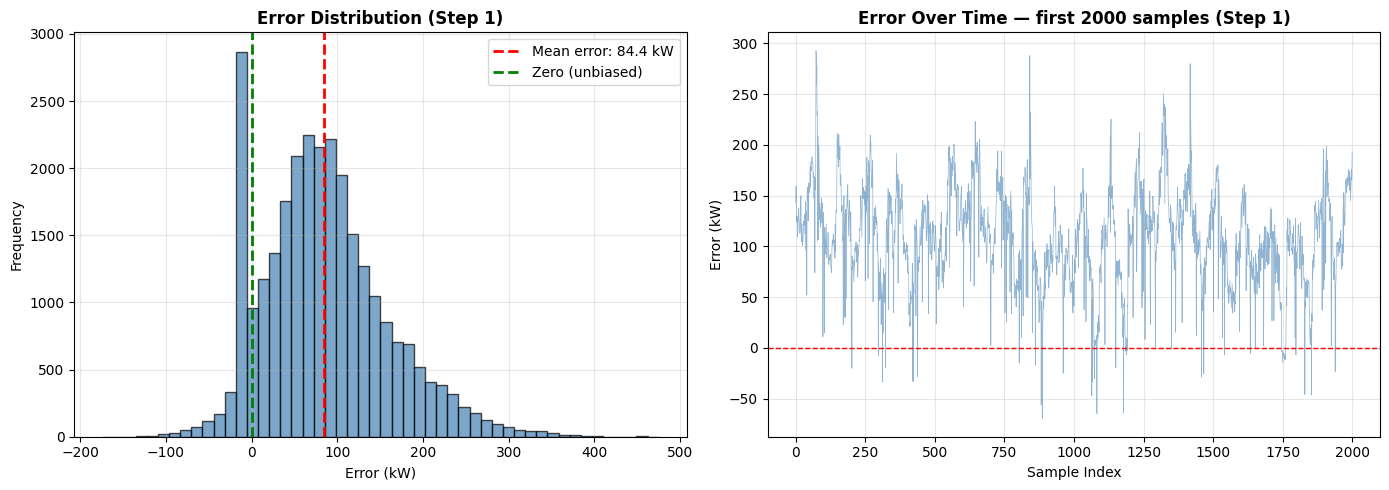

In [60]:
# ── Plot 4: Error analysis — distribution + over time (step 1)
errors = (y_te_true[:, 0] - y_te_pred[:, 0]).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: error histogram
axes[0].hist(errors, bins=50, color="steelblue", alpha=0.7, edgecolor="black")
axes[0].axvline(errors.mean(), color="red",   lw=2, linestyle="--", label=f"Mean error: {errors.mean():.1f} kW")
axes[0].axvline(0,             color="green", lw=2, linestyle="--", label="Zero (unbiased)")
axes[0].set_title("Error Distribution (Step 1)", fontweight="bold")
axes[0].set_xlabel("Error (kW)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: error over time (first 2000 samples)
axes[1].plot(errors[:2000], alpha=0.6, color="steelblue", lw=0.5)
axes[1].axhline(0, color="red", lw=1, linestyle="--")
axes[1].set_title("Error Over Time — first 2000 samples (Step 1)", fontweight="bold")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("Error (kW)")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR / "error_analysis.png", dpi=150)
plt.show()

## 1️⃣2️⃣ Save Production Config

A single `prod_config.json` file bundles everything a deployment engineer needs:
- Model path and input/output shapes
- Feature names and scaler paths
- Performance metrics
- Inference latency numbers

In [61]:
prod_config = {
    "model": {
        "name"        : "transformer_baseline",
        "version"     : "1.0",
        "path"        : ckpt_path,
        "framework"   : "tensorflow",
        "input_shape" : [CONFIG["lookback"], n_features],
        "output_shape": [CONFIG["horizon"]],
    },
    "features": {
        "lookback"     : CONFIG["lookback"],
        "n_features"   : n_features,
        "feature_names": FEATURE_COLS,
        "scaler_path"  : str(OUT_DIR / "feat_scaler.pkl"),
    },
    "target": {
        "name"        : CONFIG["target_col"],
        "unit"        : "kW",
        "scaler_path" : str(OUT_DIR / "target_scaler.pkl"),
    },
    "performance": all_metrics,
    "inference": {
        "batch_size"                 : CONFIG["batch_size"],
        "latency_ms_single"          : round(single_ms, 2),
        "latency_ms_per_sample_batch": round(batch_ms_per_sample, 2),
        "throughput_samples_per_sec" : round(1000 / batch_ms_per_sample),
    },
    "training": {
        "epochs_trained" : len(history.history["loss"]),
        "training_date"  : datetime.now().isoformat(),
        "seed"           : SEED,
    },
}

with open(OUT_DIR / "prod_config.json", "w") as f:
    json.dump(prod_config, f, indent=2)

log(f"Production config saved → {OUT_DIR / 'prod_config.json'} ✅")

[2026-07-16 08:05:29] INFO     Production config saved → outputs/prod_config.json ✅


## ✅ Deployment Summary

All artifacts saved to `outputs/`:

| File | Description |
|------|-------------|
| `transformer_baseline.keras` | Best model weights |
| `feat_scaler.pkl` | Feature scaler |
| `target_scaler.pkl` | Target scaler |
| `metrics.json` | Per-step & overall metrics for all splits |
| `prod_config.json` | Full deployment configuration |
| `training_curves.png` | Loss curves |
| `test_forecast.png` | 7-day forecast vs actual |
| `scatter.png` | Actual vs predicted scatter |
| `error_analysis.png` | Error distribution + over time |

---

### 🚀 How to Use at Deployment

```python
import joblib, numpy as np
import tensorflow as tf

# Load artifacts
model         = tf.keras.models.load_model("outputs/transformer_baseline.keras")
feat_scaler   = joblib.load("outputs/feat_scaler.pkl")
target_scaler = joblib.load("outputs/target_scaler.pkl")

# Prepare one window of raw features (196 × n_features)
X_raw    = feat_scaler.transform(features_window)          # scale
X_input  = X_raw[np.newaxis, ...]                          # add batch dim

# Predict 4 steps ahead
y_scaled = model.predict(X_input)                          # shape: (1, 4)
y_kw     = target_scaler.inverse_transform(y_scaled.reshape(-1, 1)).flatten()
# y_kw[0] = next 15 min, y_kw[3] = next 60 min
```